# Deteccion de Tumores (Benigno vs Maligno) con Red Neuronal - Dataset sklearn

## Paso 1: Importar librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# ===== CONFIGURAR SEMILLAS PARA REPRODUCIBILIDAD =====
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"\n✓ Semillas aleatorias configuradas (SEED={SEED})")

TensorFlow: 2.21.0
Pandas: 3.0.1
NumPy: 2.4.3

✓ Semillas aleatorias configuradas (SEED=42)


## Paso 2: Cargar y validar dataset desde sklearn

In [2]:
print('=== Cargar y limpiar dataset ===\n')

# Cargar dataset desde sklearn
breast = load_breast_cancer()
df = pd.DataFrame(breast.data, columns=breast.feature_names)
df['target'] = breast.target

# Columnas de features (todas excepto target)
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Features detectadas: {len(feature_cols)}")

print('\n=== Limpieza de datos ===\n')

# Verificar duplicados
duplicados_antes = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados_antes}")

if duplicados_antes > 0:
    df = df.drop_duplicates()
    print(f"  -> Eliminadas {duplicados_antes} filas duplicadas")

# Verificar valores nulos
nulos_por_columna = df.isnull().sum()
nulos_totales = nulos_por_columna.sum()
print(f"\nValores nulos por columna: {nulos_totales}")

if nulos_totales > 0:
    print("\nColumnas con valores nulos:")
    print(nulos_por_columna[nulos_por_columna > 0])
    
    # Opción 1: Eliminar filas con nulos (si son pocos)
    if nulos_totales < len(df) * 0.05:  # menos del 5%
        df = df.dropna()
        print(f"  -> Eliminadas filas con valores nulos")
    else:
        # Opción 2: Imputar con la mediana (para features numéricas)
        for col in feature_cols:
            if df[col].isnull().sum() > 0:
                mediana = df[col].median()
                df[col].fillna(mediana, inplace=True)
                print(f"  -> Imputados valores nulos en '{col}' con mediana: {mediana:.4f}")

# Verificar outliers extremos usando IQR
print(f"\n=== Detección de outliers (método IQR) ===")
outliers_totales = 0

for col in feature_cols[:5]:  # Revisar las primeras 5 features como ejemplo
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # factor 3 para outliers extremos
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers extremos detectados")
        outliers_totales += outliers

if outliers_totales == 0:
    print("No se detectaron outliers extremos en las features principales")

print(f"\n=== Dataset después de limpieza ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

# Actualizar feature_cols en caso de que se hayan eliminado columnas
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

=== Cargar y limpiar dataset ===

Dataset cargado: 569 filas, 31 columnas
Features detectadas: 30

=== Limpieza de datos ===

Filas duplicadas encontradas: 0

Valores nulos por columna: 0

=== Detección de outliers (método IQR) ===
mean radius: 1 outliers extremos detectados
mean texture: 1 outliers extremos detectados
mean area: 5 outliers extremos detectados
mean smoothness: 1 outliers extremos detectados

=== Dataset después de limpieza ===
Filas: 569
Columnas: 31
Valores nulos restantes: 0


## Paso 4: Normalización de datos

=== Normalización de datos ===

Estandarización aplicada a 30 features

Resumen de valores después de estandarización:
  Mínimo: -3.1121
  Máximo: 12.0727
  Media: -0.0000


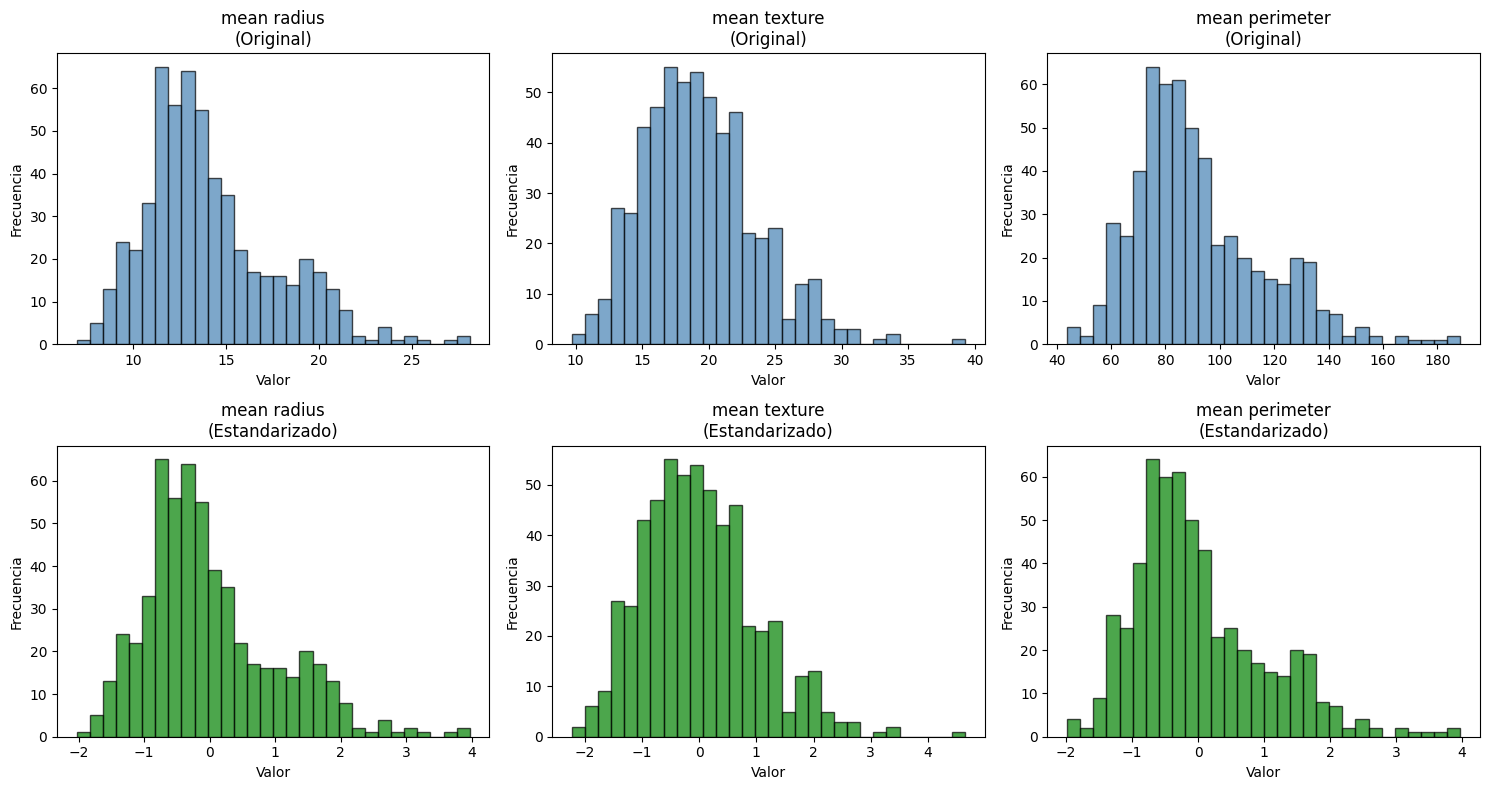


=== Dataset estandarizado ===
Filas: 569
Features estandarizadas: 30


In [3]:
print('=== Normalización de datos ===\n')

# Estandarizar las features numéricas con StandardScaler (media≈0, std≈1)
normalizer = StandardScaler()

# Estandarizar solo las columnas de features (no diagnosis ni target)
df_normalized = df.copy()
df_normalized[feature_cols] = normalizer.fit_transform(df[feature_cols])

print(f"Estandarización aplicada a {len(feature_cols)} features")
print(f"\nResumen de valores después de estandarización:")
print(f"  Mínimo: {df_normalized[feature_cols].min().min():.4f}")
print(f"  Máximo: {df_normalized[feature_cols].max().max():.4f}")
print(f"  Media: {df_normalized[feature_cols].mean().mean():.4f}")

# Visualizar comparación antes y después (primeras 3 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(feature_cols[:3]):
    # Antes de estandarizar
    axes[0, idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{col}\n(Original)')
    axes[0, idx].set_xlabel('Valor')
    axes[0, idx].set_ylabel('Frecuencia')
    
    # Después de estandarizar
    axes[1, idx].hist(df_normalized[col], bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'{col}\n(Estandarizado)')
    axes[1, idx].set_xlabel('Valor')
    axes[1, idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Actualizar el DataFrame principal con los datos estandarizados
df = df_normalized.copy()

print(f"\n=== Dataset estandarizado ===")
print(f"Filas: {df.shape[0]}")
print(f"Features estandarizadas: {len(feature_cols)}")

## Paso 5: Analisis exploratorio rapido

Valores nulos totales: 0
Benigno (0): 212
Maligno (1): 357


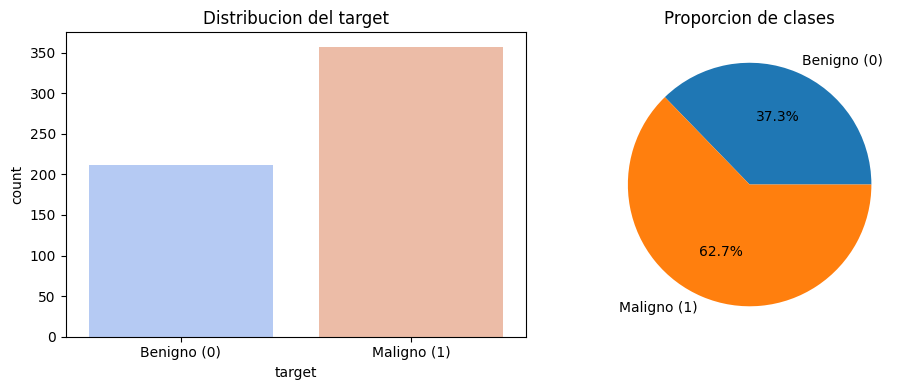

In [4]:
print('Valores nulos totales:', df.isnull().sum().sum())

conteo = df['target'].value_counts().sort_index()
print(f"Benigno (0): {conteo.get(0, 0)}")
print(f"Maligno (1): {conteo.get(1, 0)}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, hue='target', palette='coolwarm', legend=False)
plt.title('Distribucion del target')
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])

plt.subplot(1, 2, 2)
df['target'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', labels=['Benigno (0)', 'Maligno (1)'])
plt.ylabel('')
plt.title('Proporcion de clases')

plt.tight_layout()
plt.show()

## Paso 6: Preprocesamiento (train/val/test estratificado)

In [5]:
X = df[feature_cols].copy()
y = df['target'].copy()

# Los datos ya están estandarizados con StandardScaler en el Paso 4
print('Datos estandarizados - Resumen de valores:')
print(f"  Mínimo: {X.min().min():.4f}")
print(f"  Máximo: {X.max().max():.4f}\n")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print('Proporción aproximada: 64% train, 16% validation, 20% test')

# Convertir a numpy arrays (ya están estandarizados)
X_train_scaled = X_train.to_numpy()
X_val_scaled = X_val.to_numpy()
X_test_scaled = X_test.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print('\nDatos preparados para entrenamiento')
print(f"Media train: {X_train_scaled.mean():.4f}")
print(f"Std train: {X_train_scaled.std():.4f}")
print(f"Rango: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")

Datos estandarizados - Resumen de valores:
  Mínimo: -3.1121
  Máximo: 12.0727

Train: (364, 30), Validation: (91, 30), Test: (114, 30)
Proporción aproximada: 64% train, 16% validation, 20% test

Datos preparados para entrenamiento
Media train: 0.0121
Std train: 1.0252
Rango: [-2.6827, 12.0727]


## Paso 7: Crear y entrenar la red neuronal

In [6]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

print('Entrenamiento finalizado')
print(f"Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5247 - loss: 0.6868 - val_accuracy: 0.9011 - val_loss: 0.5827
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8407 - loss: 0.5368 - val_accuracy: 0.9451 - val_loss: 0.4270
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9038 - loss: 0.3982 - val_accuracy: 0.9670 - val_loss: 0.2873
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9176 - loss: 0.2923 - val_accuracy: 0.9560 - val_loss: 0.1978
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9423 - loss: 0.2164 - val_accuracy: 0.9560 - val_loss: 0.1514
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9560 - loss: 0.1779 - val_accuracy: 0.9670 - val_loss: 0.1244
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9615 - loss: 0.1451 - val_accuracy: 0.9780 - val_loss: 0.1071
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9588 - loss: 0.1397 - val_accuracy: 0.

## Paso 8: Evaluacion del modelo

In [7]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1-score:  0.9790
ROC-AUC:   0.9931

Reporte de clasificacion:
              precision    recall  f1-score   support

 Benigno (0)       0.95      0.98      0.96        42
 Maligno (1)       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



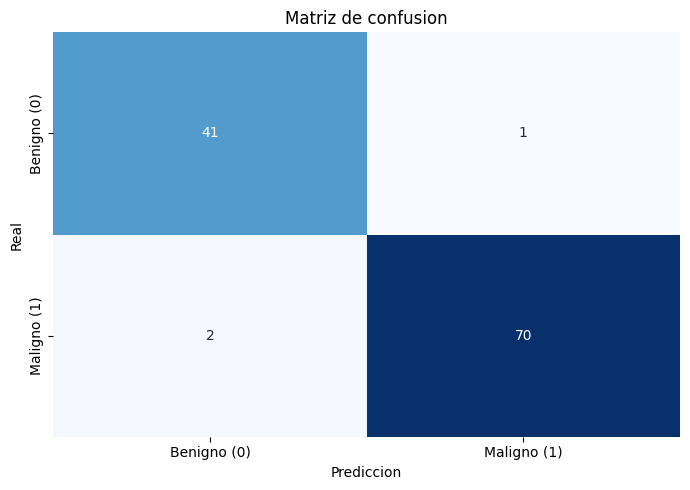

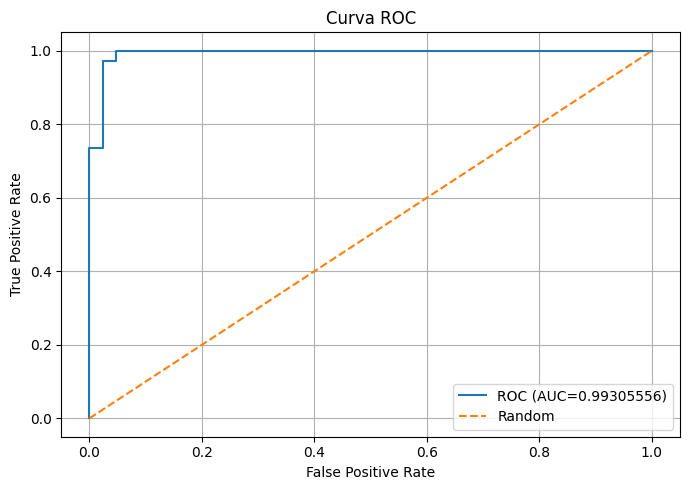

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.yticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.8f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Paso 9: Prediccion para nuevos parametros

In [9]:
TARGET_MAP = {0: 'Benigno', 1: 'Maligno'}

def predecir_tumor(parametros_entrada, modelo, normalizador, columnas_modelo, umbral=0.5):
    """
    parametros_entrada: dict con las 30 features del dataset sklearn.
    modelo: modelo de red neuronal entrenado.
    normalizador: StandardScaler ajustado en el Paso 4.
    columnas_modelo: lista de nombres de features.
    umbral: umbral de clasificación (default 0.5).
    """
    faltantes = [c for c in columnas_modelo if c not in parametros_entrada]
    if faltantes:
        raise ValueError(f'Faltan parametros: {faltantes}')

    x_df = pd.DataFrame([parametros_entrada], columns=columnas_modelo)
    x_normalized = normalizador.transform(x_df)

    prob_maligno = float(modelo.predict(x_normalized, verbose=0).flatten()[0])
    prob_benigno = 1.0 - prob_maligno
    pred = 1 if prob_maligno >= umbral else 0

    return {
        'prob_maligno': prob_maligno,
        'prob_benigno': prob_benigno,
        'pred_clase': pred,
        'pred_etiqueta': TARGET_MAP[pred],
    }

# Ejemplo de uso con los promedios del dataset
PARAMETROS_USUARIO = X.mean().to_dict()

resultado = predecir_tumor(
    PARAMETROS_USUARIO,
    modelo=model,
    normalizador=normalizer,  # StandardScaler ajustado en el Paso 4
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print('=== Resultado de prediccion ===')
print(f"Prob. maligno: {resultado['prob_maligno']:.4f}")
print(f"Prob. benigno: {resultado['prob_benigno']:.4f}")
print(f"Clase predicha: {resultado['pred_clase']} -> {resultado['pred_etiqueta']}")

=== Resultado de prediccion ===
Prob. maligno: 1.0000
Prob. benigno: 0.0000
Clase predicha: 1 -> Maligno


In [10]:
# Diagnostico rapido de por que el modelo aprende
corr_abs = df[feature_cols + ['target']].corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

print('Top 10 correlaciones absolutas con target:')
print(corr_abs.head(10))
print(f'\nCorrelacion maxima abs: {corr_abs.max():.4f}')
print(f'Correlacion media abs: {corr_abs.mean():.4f}')

print('\nDistribucion de clases en dataset completo:')
print(df['target'].value_counts(normalize=True).sort_index())

print('\nValores minimos por feature (primeras 10):')
print(df[feature_cols].min().head(10))

Top 10 correlaciones absolutas con target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64

Correlacion maxima abs: 0.7936
Correlacion media abs: 0.4703

Distribucion de clases en dataset completo:
target
0    0.372583
1    0.627417
Name: proportion, dtype: float64

Valores minimos por feature (primeras 10):
mean radius              -2.029648
mean texture             -2.229249
mean perimeter           -1.984504
mean area                -1.454443
mean smoothness          -3.112085
mean compactness         -1.610136
mean concavity           -1.114873
mean concave points      -1.261820
mean symmetry            -2.744117
mean fractal dimension   -1.819865
dtype: float64


## Paso 10: Ingresar datos personalizados

In [11]:
# Mostrar rangos de referencia del dataset original (antes de normalizar)
print("=" * 70)
print("RANGOS DE REFERENCIA (valores del dataset original)")
print("=" * 70)

# Cargar dataset original para mostrar rangos reales
breast_ref = load_breast_cancer()
df_ref = pd.DataFrame(breast_ref.data, columns=breast_ref.feature_names)

print(f"\n{'Feature':<30} {'Min':>12} {'Max':>12} {'Promedio':>12}")
print("-" * 70)
for col in feature_cols:
    print(f"{col:<30} {df_ref[col].min():>12.4f} {df_ref[col].max():>12.4f} {df_ref[col].mean():>12.4f}")

print("\n" + "=" * 70)

RANGOS DE REFERENCIA (valores del dataset original)

Feature                                 Min          Max     Promedio
----------------------------------------------------------------------
mean radius                          6.9810      28.1100      14.1273
mean texture                         9.7100      39.2800      19.2896
mean perimeter                      43.7900     188.5000      91.9690
mean area                          143.5000    2501.0000     654.8891
mean smoothness                      0.0526       0.1634       0.0964
mean compactness                     0.0194       0.3454       0.1043
mean concavity                       0.0000       0.4268       0.0888
mean concave points                  0.0000       0.2012       0.0489
mean symmetry                        0.1060       0.3040       0.1812
mean fractal dimension               0.0500       0.0974       0.0628
radius error                         0.1115       2.8730       0.4052
texture error                       

DATOS INGRESADOS
  mean radius: 14.127
  mean texture: 19.289
  mean perimeter: 91.969
  mean area: 654.889
  mean smoothness: 0.096
  mean compactness: 0.104
  mean concavity: 0.089
  mean concave points: 0.049
  mean symmetry: 0.181
  mean fractal dimension: 0.063
  radius error: 0.405
  texture error: 1.217
  perimeter error: 2.866
  area error: 40.337
  smoothness error: 0.007
  compactness error: 0.025
  concavity error: 0.032
  concave points error: 0.012
  symmetry error: 0.021
  fractal dimension error: 0.004
  worst radius: 16.269
  worst texture: 25.677
  worst perimeter: 107.261
  worst area: 880.583
  worst smoothness: 0.132
  worst compactness: 0.254
  worst concavity: 0.272
  worst concave points: 0.115
  worst symmetry: 0.29
  worst fractal dimension: 0.084

RESULTADO DE LA PREDICCION

  Probabilidad de BENIGNO:  27.19%
  Probabilidad de MALIGNO:  72.81%

  >>> DIAGNOSTICO: MALIGNO <<<



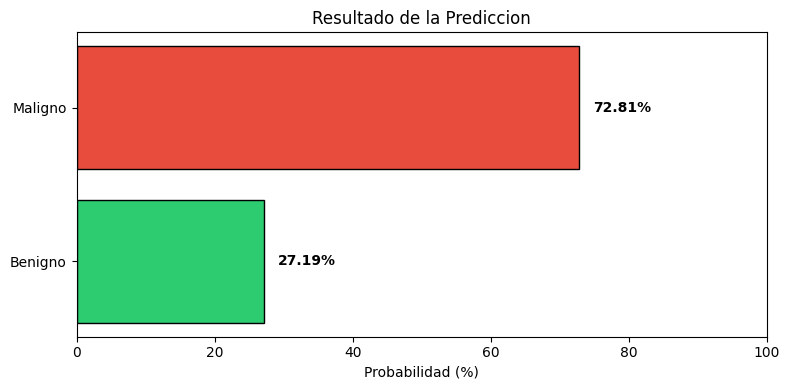

In [12]:
# Modifica los valores segun tus mediciones.
# Los valores por defecto son los promedios del dataset.

MIS_DATOS = {
    # ----- MEDIDAS MEAN (promedio de las celulas) -----
    'mean radius':             14.127,    # Radio promedio
    'mean texture':            19.289,    # Textura promedio
    'mean perimeter':          91.969,    # Perimetro promedio
    'mean area':               654.889,   # Area promedio
    'mean smoothness':         0.096,     # Suavidad promedio
    'mean compactness':        0.104,     # Compacidad promedio
    'mean concavity':          0.089,     # Concavidad promedio
    'mean concave points':     0.049,     # Puntos concavos promedio
    'mean symmetry':           0.181,     # Simetria promedio
    'mean fractal dimension':  0.063,     # Dimension fractal promedio
    
    # ----- MEDIDAS SE (error estandar) -----
    'radius error':            0.405,     # Error del radio
    'texture error':           1.217,     # Error de textura
    'perimeter error':         2.866,     # Error del perimetro
    'area error':              40.337,    # Error del area
    'smoothness error':        0.007,     # Error de suavidad
    'compactness error':       0.025,     # Error de compacidad
    'concavity error':         0.032,     # Error de concavidad
    'concave points error':    0.012,     # Error de puntos concavos
    'symmetry error':          0.021,     # Error de simetria
    'fractal dimension error': 0.004,     # Error de dimension fractal
    
    # ----- MEDIDAS WORST (peor valor / mas grande) -----
    'worst radius':            16.269,    # Peor radio
    'worst texture':           25.677,    # Peor textura
    'worst perimeter':         107.261,   # Peor perimetro
    'worst area':              880.583,   # Peor area
    'worst smoothness':        0.132,     # Peor suavidad
    'worst compactness':       0.254,     # Peor compacidad
    'worst concavity':         0.272,     # Peor concavidad
    'worst concave points':    0.115,     # Peor puntos concavos
    'worst symmetry':          0.290,     # Peor simetria
    'worst fractal dimension': 0.084,     # Peor dimension fractal
}

# ============================================================================
# EJECUTAR PREDICCION
# ============================================================================

print("=" * 70)
print("DATOS INGRESADOS")
print("=" * 70)
for key, value in MIS_DATOS.items():
    print(f"  {key}: {value}")

# Realizar prediccion
resultado = predecir_tumor(
    MIS_DATOS,
    modelo=model,
    normalizador=normalizer,
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print("\n" + "=" * 70)
print("RESULTADO DE LA PREDICCION")
print("=" * 70)
print(f"\n  Probabilidad de BENIGNO:  {resultado['prob_benigno']*100:.2f}%")
print(f"  Probabilidad de MALIGNO:  {resultado['prob_maligno']*100:.2f}%")
print(f"\n  >>> DIAGNOSTICO: {resultado['pred_etiqueta'].upper()} <<<")
print("\n" + "=" * 70)

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Benigno', 'Maligno']
probabilidades = [resultado['prob_benigno']*100, resultado['prob_maligno']*100]
colores = ['#2ecc71', '#e74c3c']

bars = ax.barh(categorias, probabilidades, color=colores, edgecolor='black')
ax.set_xlim(0, 100)
ax.set_xlabel('Probabilidad (%)')
ax.set_title('Resultado de la Prediccion')

for bar, prob in zip(bars, probabilidades):
    ax.text(prob + 2, bar.get_y() + bar.get_height()/2, f'{prob:.2f}%', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis de Parámetros y Decisiones

### Parámetros utilizados en el modelo
- **Arquitectura de la red neuronal**: Red secuencial con capas Dense de 64, 32 y 16 neuronas (ReLU), más una salida sigmoid para clasificación binaria. Se aplicó Dropout de 0.30, 0.20 y 0.10 para regularización.
- **Optimizador**: Adam.
- **Función de pérdida**: Binary Crossentropy.
- **Métrica de entrenamiento**: Accuracy.
- **Early Stopping**: `monitor='val_loss'`, `patience=15`, `restore_best_weights=True`.
- **Épocas y lote**: hasta 100 épocas con `batch_size=32`.

### Separación de datos
Se usó separación estratificada en dos pasos:
1. 80% temporal y 20% prueba.
2. Del 80% temporal, 80% entrenamiento y 20% validación.

La proporción final es aproximadamente **64% entrenamiento, 16% validación y 20% prueba**. Esto conserva la distribución de clases en cada subconjunto.

### Preprocesamiento usado en entrenamiento
En el Paso 4 se aplicó **StandardScaler** a las features numéricas. Por lo tanto, el entrenamiento del Paso 7 se realizó con datos **estandarizados** (media cercana a 0 y desviación estándar cercana a 1), no con escala [0,1].

### Efectividad del modelo con esta configuración
Con la configuración actual (StandardScaler + red neuronal + early stopping), el modelo mantiene un rendimiento alto en prueba (accuracy, precisión, recall, F1 y ROC-AUC). Esto indica que la estandarización y la arquitectura elegida son consistentes con el comportamiento observado del entrenamiento.

### Nota práctica
Si en un futuro trabajas con datos con outliers más severos, conviene evaluar `RobustScaler` o aplicar tratamiento de outliers antes de estandarizar.

## Resumen del modelo y pruebas

### 1) Estructura del modelo
El modelo es una red neuronal secuencial para clasificación binaria (Benigno vs Maligno):
- **Entrada**: `Input(shape=(num_features,))` con las 30 variables clínicas del dataset.
- **Capas ocultas**: `Dense(64) -> Dense(32) -> Dense(16)` con activación `relu`.
- **Regularización**: `Dropout(0.30)`, `Dropout(0.20)` y `Dropout(0.10)` entre capas para reducir sobreajuste.
- **Salida**: `Dense(1, activation='sigmoid')` para obtener probabilidad de malignidad en rango `[0, 1]`.

### 2) Componentes del modelo
En el código, los componentes clave son:
- **Preprocesamiento**:
  - Limpieza de duplicados/nulos y revisión de outliers.
  - Escalado con `StandardScaler` (aunque en comentarios aparece `[0,1]`, la implementación actual estandariza media 0 y desviación 1).
  - División estratificada `train/val/test` para mantener proporción de clases.
- **Compilación y entrenamiento**:
  - Optimizador: `adam`.
  - Pérdida: `binary_crossentropy`.
  - Métrica principal: `accuracy`.
  - `EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)` para detener cuando no mejora validación.
- **Evaluación**:
  - Métricas: `accuracy`, `precision`, `recall`, `f1`, `roc_auc`.
  - Visualización con matriz de confusión y curva ROC.
- **Predicción de nuevos casos**:
  - Función `predecir_tumor(...)` que transforma los datos con el mismo normalizador y devuelve probabilidad + clase final.

### 3) Resultados de diferentes pruebas (según el flujo del código)
El notebook realiza varias pruebas para validar el desempeño:
- **Prueba de entrenamiento/validación**:
  - Se observa `val_loss` por época y se seleccionan los mejores pesos con `EarlyStopping`.
- **Prueba final en test**:
  - Se calcula el rendimiento real fuera de entrenamiento con `Accuracy`, `Precision`, `Recall`, `F1` y `ROC-AUC`.
- **Prueba visual de clasificación**:
  - La matriz de confusión muestra aciertos/errores por clase.
  - La curva ROC y su AUC indican capacidad de discriminación (más cerca de 1.0, mejor).
- **Prueba con datos personalizados**:
  - Al ingresar `MIS_DATOS`, el modelo entrega probabilidades de benigno/maligno y un diagnóstico final.

**Conclusión práctica:** el código combina validación durante entrenamiento, evaluación estadística en test y prueba de inferencia con nuevos datos, lo que da una verificación completa del comportamiento del modelo.

## Examen oral: 30 preguntas con respuesta sobre la red neuronal

### Nivel fácil
1. **¿Qué problema resuelve la red neuronal en este proyecto?**  
   **Respuesta:** Un problema de **clasificación**, donde el modelo predice a qué clase pertenece cada muestra.

2. **¿Cuál es la variable objetivo (target)?**  
   **Respuesta:** La columna que representa la clase final a predecir (diagnóstico/etiqueta del dataset).

3. **¿Qué tipo de arquitectura se usó?**  
   **Respuesta:** Una red neuronal **densa (MLP)** con capas completamente conectadas.

4. **¿Cuántas partes principales tiene la red?**  
   **Respuesta:** Capa de entrada, una o más capas ocultas y capa de salida.

5. **¿Qué hace una neurona en una capa densa?**  
   **Respuesta:** Calcula una combinación lineal de entradas y luego aplica una función de activación.

6. **¿Qué activación se suele usar en capas ocultas?**  
   **Respuesta:** Generalmente **ReLU**, porque acelera el entrenamiento y reduce saturación.

7. **¿Qué activación se usa en la salida para clasificación binaria?**  
   **Respuesta:** **Sigmoid**, porque entrega una probabilidad entre 0 y 1.

8. **¿Qué función de pérdida es común en clasificación binaria?**  
   **Respuesta:** **Binary crossentropy**.

9. **¿Qué optimizador se usa comúnmente?**  
   **Respuesta:** **Adam**, por su buena convergencia en muchos problemas.

10. **¿Qué métrica simple se reporta primero?**  
    **Respuesta:** **Accuracy (exactitud)**.

### Nivel intermedio
11. **¿Qué significa normalizar datos?**  
    **Respuesta:** Escalar variables para que estén en rangos comparables y el modelo entrene mejor.

12. **¿Por qué es importante normalizar en redes neuronales?**  
    **Respuesta:** Porque estabiliza gradientes, acelera convergencia y mejora rendimiento.

13. **¿Qué métodos de normalización son comunes?**  
    **Respuesta:** **Min-Max** y **StandardScaler (media 0, desviación 1)**.

14. **¿En qué momento correcto se ajusta el escalador?**  
    **Respuesta:** Se ajusta **solo con entrenamiento** y luego se transforma validación/prueba.

15. **¿Cómo se dividen los datos?**  
    **Respuesta:** En entrenamiento, validación y prueba para entrenar, ajustar y evaluar de forma justa.

16. **¿Qué es overfitting?**  
    **Respuesta:** Cuando el modelo memoriza entrenamiento pero generaliza mal en datos nuevos.

17. **¿Cómo se reduce el overfitting?**  
    **Respuesta:** Con **dropout**, regularización L2, early stopping y arquitectura más simple.

18. **¿Qué hace Dropout?**  
    **Respuesta:** Apaga neuronas aleatoriamente durante entrenamiento para mejorar generalización.

19. **¿Qué indica que el modelo está aprendiendo en las curvas?**  
    **Respuesta:** Que baja la pérdida de entrenamiento y validación, sin separarse demasiado.

20. **¿Qué pasa si la pérdida de train baja y la de validación sube?**  
    **Respuesta:** Señal clásica de **sobreajuste**.

### Nivel difícil
21. **¿Por qué crossentropy suele ser mejor que MSE en clasificación?**  
    **Respuesta:** Porque está alineada con probabilidades y penaliza mejor errores de clasificación.

22. **¿Cómo afecta la tasa de aprendizaje (learning rate)?**  
    **Respuesta:** Muy alta puede inestabilizar; muy baja vuelve lento el entrenamiento.

23. **¿Qué diferencia hay entre precisión, recall y F1?**  
    **Respuesta:** Precisión mide aciertos entre positivos predichos, recall detectados entre positivos reales, y F1 balancea ambos.

24. **¿Por qué accuracy sola puede ser engañosa?**  
    **Respuesta:** En clases desbalanceadas puede verse alta aunque falle en la clase minoritaria.

25. **¿Cómo manejarías clases desbalanceadas?**  
    **Respuesta:** Con class weights, sobremuestreo (SMOTE) o ajuste de umbral.

26. **¿Qué es el umbral de decisión y por qué importa?**  
    **Respuesta:** Es el corte para convertir probabilidad en clase; cambiarlo altera precisión/recall.

27. **¿Cómo compararías este modelo con uno baseline?**  
    **Respuesta:** Mismas particiones, mismas métricas y validación consistente para comparación justa.

28. **¿Qué evidencia usarías para defender que generaliza bien?**  
    **Respuesta:** Buen rendimiento en test, brecha pequeña train-val y estabilidad en validación cruzada.

29. **¿Qué experimento de ablación propondrías?**  
    **Respuesta:** Quitar una capa o dropout y medir cuánto cae el desempeño para estimar su aporte.

30. **Si te piden mejorar el modelo sin subir mucho costo, qué harías?**  
    **Respuesta:** Ajustar hiperparámetros, usar early stopping, reducir capas innecesarias y optimizar umbral/métricas según el objetivo clínico.